In [169]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

In [170]:
nri_1 = pd.read_parquet(
    "../../01_original_data/NRI/NRI_Table_CensusTracts_01.parquet", engine="pyarrow"
)
nri_2 = pd.read_parquet(
    "../../01_original_data/NRI/NRI_Table_CensusTracts_02.parquet", engine="pyarrow"
)
nri = pd.concat([nri_1, nri_2], ignore_index=True)
nri.columns = [re.sub(r"\s+", "_", c.strip().lower()) for c in nri.columns]
nri["stcofips"] = nri["statefips"].astype(str).str.zfill(2) + nri["countyfips"].astype(
    str
).str.zfill(3)
nri = nri[
    [
        "state",
        "stateabbrv",
        "county",
        "statefips",
        "stcofips",
        "population",
        "risk_value",
        "risk_score",
        "risk_ratng",
    ]
]
# nri.info()
nri.head(10)

,state,stateabbrv,county,statefips,stcofips,population,risk_value,risk_score,risk_ratng
0,Alabama,AL,Autauga,1,01001,1775,188698.407566,15.783903,Very Low
1,Alabama,AL,Autauga,1,01001,2055,340553.014519,33.747562,Relatively Low
2,Alabama,AL,Autauga,1,01001,3216,330586.742472,32.685630,Relatively Low
3,Alabama,AL,Autauga,1,01001,4246,339127.095367,33.598915,Relatively Low
4,Alabama,AL,Autauga,1,01001,4322,356499.020920,35.368406,Relatively Low
5,Alabama,AL,Autauga,1,01001,3284,214422.040039,18.944727,Very Low
6,Alabama,AL,Autauga,1,01001,3616,299439.901146,29.257242,Relatively Low
7,Alabama,AL,Autauga,1,01001,3729,412327.837288,40.656662,Relatively Low
8,Alabama,AL,Autauga,1,01001,3383,581612.075617,53.216715,Relatively Low
9,Alabama,AL,Autauga,1,01001,3143,343342.631133,34.021072,Relatively Low


In [171]:
nri = nri.dropna(subset=["risk_score", "risk_value", "risk_ratng", "population"])
nri["risk_score"] = pd.to_numeric(nri["risk_score"], errors="coerce")
nri["risk_value"] = pd.to_numeric(nri["risk_value"], errors="coerce")
nri = nri.groupby("stcofips", as_index=False).agg(
    {
        "state": "first",
        "stateabbrv": "first",
        "county": "first",
        "risk_score": "mean",
        "risk_value": "mean",
        # if risk_ratng is text, use mode (most frequent)
        "risk_ratng": lambda x: x.mode().iat[0] if not x.mode().empty else None,
        "population": "sum",
    }
)

nri

,stcofips,state,stateabbrv,county,risk_score,risk_value,risk_ratng,population
0,01001,Alabama,AL,Autauga,34.218405,3.621208e+05,Relatively Low,58764
1,01003,Alabama,AL,Baldwin,95.521931,4.898435e+06,Relatively High,231365
2,01005,Alabama,AL,Barbour,61.860951,8.236488e+05,Relatively Moderate,25160
3,01007,Alabama,AL,Bibb,43.452707,4.829684e+05,Relatively Low,22239
4,01009,Alabama,AL,Blount,53.285687,6.399085e+05,Relatively Low,58992
...,...,...,...,...,...,...,...,...
3138,56037,Wyoming,WY,Sweetwater,5.511820,9.146777e+04,Very Low,42238
3139,56039,Wyoming,WY,Teton,67.457241,1.630223e+06,Relatively Moderate,23250
3140,56041,Wyoming,WY,Uinta,40.515943,4.702302e+05,Relatively Low,20412
3141,56043,Wyoming,WY,Washakie,17.921245,2.070654e+05,Very Low,7662


In [172]:
hpi = pd.read_csv(
    "../../01_original_data/federal_housing_finance_agency/hpi_master.csv"
)
print(min(hpi["yr"]))
hpi = hpi[
    (hpi["level"] == "MSA") & (hpi["yr"].isin([2022, 2023]))
]  # only keep data for msa level
hpi = hpi[["place_name", "place_id", "yr", "period", "index_nsa"]]
# hpi.info()
hpi

1975


,place_name,place_id,yr,period,index_nsa
4283,"Abilene, TX",10180,2022,1,290.21
4284,"Abilene, TX",10180,2022,2,305.79
4285,"Abilene, TX",10180,2022,3,307.89
4286,"Abilene, TX",10180,2022,4,297.38
4287,"Abilene, TX",10180,2023,1,320.70
...,...,...,...,...,...
131270,"Warren-Troy-Farmington Hills, MI (MSAD)",47664,2022,4,309.93
131271,"Warren-Troy-Farmington Hills, MI (MSAD)",47664,2023,1,315.65
131272,"Warren-Troy-Farmington Hills, MI (MSAD)",47664,2023,2,328.89
131273,"Warren-Troy-Farmington Hills, MI (MSAD)",47664,2023,3,336.58


In [173]:
hpi = hpi.groupby(["place_id", "yr"], as_index=False).agg(
    {
        "place_name": "first",
        "place_id": "first",
        "yr": "first",
        "index_nsa": "mean",
    }
)

hpi["index_prev"] = hpi.groupby(["place_id"])["index_nsa"].shift(1)

hpi

,place_name,place_id,yr,index_nsa,index_prev
0,"Abilene, TX",10180,2022,300.3175,NaN
1,"Abilene, TX",10180,2023,327.3250,300.3175
2,"Akron, OH",10420,2022,216.7675,NaN
3,"Akron, OH",10420,2023,231.3750,216.7675
4,"Albany, GA",10500,2022,213.3175,NaN
...,...,...,...,...,...
815,"Youngstown-Warren, OH",49660,2023,232.7800,216.0650
816,"Yuba City, CA",49700,2022,362.1900,NaN
817,"Yuba City, CA",49700,2023,359.3725,362.1900
818,"Yuma, AZ",49740,2022,302.8575,NaN


In [174]:
xwalk = pd.read_csv(
    "../../01_original_data/federal_housing_finance_agency/list1_2023.csv"
)
xwalk.columns = (
    xwalk.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
)
xwalk["county_fips5"] = (
    xwalk["fips_state_code"].astype(str).str.upper().str.strip().str.zfill(2)
    + xwalk["fips_county_code"].astype(str).str.zfill(3).str.strip()
)
xwalk = xwalk[
    [
        "cbsa_code",
        "cbsa_title",
        "county_fips5",
        "county/county_equivalent",
        "state_name",
    ]
]
xwalk["cbsa_code"] = xwalk["cbsa_code"].astype(str)
# xwalk.info()
xwalk

,cbsa_code,cbsa_title,county_fips5,county/county_equivalent,state_name
0,10100,"Aberdeen, SD",46013,Brown County,South Dakota
1,10100,"Aberdeen, SD",46045,Edmunds County,South Dakota
2,10140,"Aberdeen, WA",53027,Grays Harbor County,Washington
3,10180,"Abilene, TX",48059,Callahan County,Texas
4,10180,"Abilene, TX",48253,Jones County,Texas
...,...,...,...,...,...
1910,49700,"Yuba City, CA",06101,Sutter County,California
1911,49700,"Yuba City, CA",06115,Yuba County,California
1912,49740,"Yuma, AZ",04027,Yuma County,Arizona
1913,49780,"Zanesville, OH",39119,Muskingum County,Ohio


In [175]:
# merge NRI with crosswalk on county fips
nri = nri.merge(
    xwalk[["cbsa_code", "county_fips5"]],
    left_on="stcofips",
    right_on="county_fips5",
    how="left",
)
nri

,stcofips,state,stateabbrv,county,risk_score,risk_value,risk_ratng,population,cbsa_code,county_fips5
0,01001,Alabama,AL,Autauga,34.218405,3.621208e+05,Relatively Low,58764,33860,01001
1,01003,Alabama,AL,Baldwin,95.521931,4.898435e+06,Relatively High,231365,19300,01003
2,01005,Alabama,AL,Barbour,61.860951,8.236488e+05,Relatively Moderate,25160,21640,01005
3,01007,Alabama,AL,Bibb,43.452707,4.829684e+05,Relatively Low,22239,13820,01007
4,01009,Alabama,AL,Blount,53.285687,6.399085e+05,Relatively Low,58992,13820,01009
...,...,...,...,...,...,...,...,...,...,...
3138,56037,Wyoming,WY,Sweetwater,5.511820,9.146777e+04,Very Low,42238,40540,56037
3139,56039,Wyoming,WY,Teton,67.457241,1.630223e+06,Relatively Moderate,23250,27220,56039
3140,56041,Wyoming,WY,Uinta,40.515943,4.702302e+05,Relatively Low,20412,21740,56041
3141,56043,Wyoming,WY,Washakie,17.921245,2.070654e+05,Very Low,7662,NaN,NaN


In [176]:
# merge NRI with HPI on msa code
nri = nri.merge(
    hpi,
    left_on="cbsa_code",
    right_on="place_id",
    how="left",
)
# nri.isna().sum()
nri

,stcofips,state,stateabbrv,county,risk_score,risk_value,risk_ratng,population,cbsa_code,county_fips5,place_name,place_id,yr,index_nsa,index_prev
0,01001,Alabama,AL,Autauga,34.218405,3.621208e+05,Relatively Low,58764,33860,01001,"Montgomery, AL",33860,2022.0,195.3500,NaN
1,01001,Alabama,AL,Autauga,34.218405,3.621208e+05,Relatively Low,58764,33860,01001,"Montgomery, AL",33860,2023.0,205.8625,195.3500
2,01003,Alabama,AL,Baldwin,95.521931,4.898435e+06,Relatively High,231365,19300,01003,"Daphne-Fairhope-Foley, AL",19300,2022.0,333.1125,NaN
3,01003,Alabama,AL,Baldwin,95.521931,4.898435e+06,Relatively High,231365,19300,01003,"Daphne-Fairhope-Foley, AL",19300,2023.0,363.1425,333.1125
4,01005,Alabama,AL,Barbour,61.860951,8.236488e+05,Relatively Moderate,25160,21640,01005,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4177,56037,Wyoming,WY,Sweetwater,5.511820,9.146777e+04,Very Low,42238,40540,56037,NaN,NaN,NaN,NaN,NaN
4178,56039,Wyoming,WY,Teton,67.457241,1.630223e+06,Relatively Moderate,23250,27220,56039,NaN,NaN,NaN,NaN,NaN
4179,56041,Wyoming,WY,Uinta,40.515943,4.702302e+05,Relatively Low,20412,21740,56041,NaN,NaN,NaN,NaN,NaN
4180,56043,Wyoming,WY,Washakie,17.921245,2.070654e+05,Very Low,7662,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [177]:
nri.columns

Index(['stcofips', 'state', 'stateabbrv', 'county', 'risk_score', 'risk_value',
       'risk_ratng', 'population', 'cbsa_code', 'county_fips5', 'place_name',
       'place_id', 'yr', 'index_nsa', 'index_prev'],
      dtype='object')

In [178]:
from scipy.stats import pearsonr

# Assume your merged DataFrame is called:
df = nri.copy()

# Ensure correct types
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["index_nsa"] = pd.to_numeric(df["index_nsa"], errors="coerce")
df["risk_score"] = pd.to_numeric(df["risk_score"], errors="coerce")

df["hpi_yoy"] = (df["index_nsa"] / df["index_prev"] - 1) * 100
df

,stcofips,state,stateabbrv,county,risk_score,risk_value,risk_ratng,population,cbsa_code,county_fips5,place_name,place_id,yr,index_nsa,index_prev,hpi_yoy
0,01001,Alabama,AL,Autauga,34.218405,3.621208e+05,Relatively Low,58764,33860,01001,"Montgomery, AL",33860,2022.0,195.3500,NaN,NaN
1,01001,Alabama,AL,Autauga,34.218405,3.621208e+05,Relatively Low,58764,33860,01001,"Montgomery, AL",33860,2023.0,205.8625,195.3500,5.381367
2,01003,Alabama,AL,Baldwin,95.521931,4.898435e+06,Relatively High,231365,19300,01003,"Daphne-Fairhope-Foley, AL",19300,2022.0,333.1125,NaN,NaN
3,01003,Alabama,AL,Baldwin,95.521931,4.898435e+06,Relatively High,231365,19300,01003,"Daphne-Fairhope-Foley, AL",19300,2023.0,363.1425,333.1125,9.014972
4,01005,Alabama,AL,Barbour,61.860951,8.236488e+05,Relatively Moderate,25160,21640,01005,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4177,56037,Wyoming,WY,Sweetwater,5.511820,9.146777e+04,Very Low,42238,40540,56037,NaN,NaN,NaN,NaN,NaN,NaN
4178,56039,Wyoming,WY,Teton,67.457241,1.630223e+06,Relatively Moderate,23250,27220,56039,NaN,NaN,NaN,NaN,NaN,NaN
4179,56041,Wyoming,WY,Uinta,40.515943,4.702302e+05,Relatively Low,20412,21740,56041,NaN,NaN,NaN,NaN,NaN,NaN
4180,56043,Wyoming,WY,Washakie,17.921245,2.070654e+05,Very Low,7662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [179]:
# df["hpi_yoy"] = df["hpi_yoy"].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["hpi_yoy", "risk_score"])
df

,stcofips,state,stateabbrv,county,risk_score,risk_value,risk_ratng,population,cbsa_code,county_fips5,place_name,place_id,yr,index_nsa,index_prev,hpi_yoy
1,01001,Alabama,AL,Autauga,34.218405,3.621208e+05,Relatively Low,58764,33860,01001,"Montgomery, AL",33860,2023.0,205.86250,195.3500,5.381367
3,01003,Alabama,AL,Baldwin,95.521931,4.898435e+06,Relatively High,231365,19300,01003,"Daphne-Fairhope-Foley, AL",19300,2023.0,363.14250,333.1125,9.014972
6,01007,Alabama,AL,Bibb,43.452707,4.829684e+05,Relatively Low,22239,13820,01007,"Birmingham, AL",13820,2023.0,324.80125,308.8250,5.173237
8,01009,Alabama,AL,Blount,53.285687,6.399085e+05,Relatively Low,58992,13820,01009,"Birmingham, AL",13820,2023.0,324.80125,308.8250,5.173237
12,01015,Alabama,AL,Calhoun,53.674516,6.903638e+05,Relatively Low,116250,11500,01015,"Anniston-Oxford, AL",11500,2023.0,261.24750,243.6425,7.225751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4149,55131,Wisconsin,WI,Washington,39.385673,4.208938e+05,Relatively Low,136723,33340,55131,"Milwaukee-Waukesha, WI",33340,2023.0,348.21250,322.0800,8.113667
4151,55133,Wisconsin,WI,Waukesha,26.722858,2.829698e+05,Relatively Low,406817,33340,55133,"Milwaukee-Waukesha, WI",33340,2023.0,348.21250,322.0800,8.113667
4155,55139,Wisconsin,WI,Winnebago,38.355452,4.082452e+05,Relatively Low,171623,36780,55139,"Oshkosh-Neenah, WI",36780,2023.0,281.44750,254.2275,10.706946
4168,56021,Wyoming,WY,Laramie,56.900775,7.656586e+05,Relatively Low,100483,16940,56021,"Cheyenne, WY",16940,2023.0,360.12750,356.7625,0.943205


In [ ]:
# --- Correlation Analysis ---
# Average risk per geography (static) vs average HPI YoY
# This is at the MSA Level - MSA is larger than county
# geo_corr = (
#     df.groupby("place_id")
#     .agg(avg_hpi_yoy=("hpi_yoy", "mean"), avg_risk=("risk_score", "mean"))
#     .dropna()
#     .reset_index()
# )

# geo_corr = geo_corr.merge(
#     right=xwalk[["cbsa_code", "cbsa_title"]].drop_duplicates(),
#     left_on="place_id",
#     right_on="cbsa_code",
#     how="left",
# )

r, p = pearsonr(df["risk_score"], df["hpi_yoy"])
print(f"Pearson correlation (risk vs HPI YoY): r={r:.3f}, p={p:.4g}")

# --- Panel Regression (time FE) ---
# Model: HPI YoY ~ Risk Score + Year Fixed Effects
model = smf.ols("hpi_yoy ~ risk_score + C(yr)", data=df).fit(
    cov_type="cluster", cov_kwds={"groups": df["place_id"]}
)

print(model.summary().tables[1])  # coefficients table
# geo_corr

Pearson correlation (avg risk vs avg HPI YoY): r=-0.246, p=8.01e-16
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.7420      0.369     21.000      0.000       7.019       8.465
risk_score    -0.0343      0.007     -5.020      0.000      -0.048      -0.021


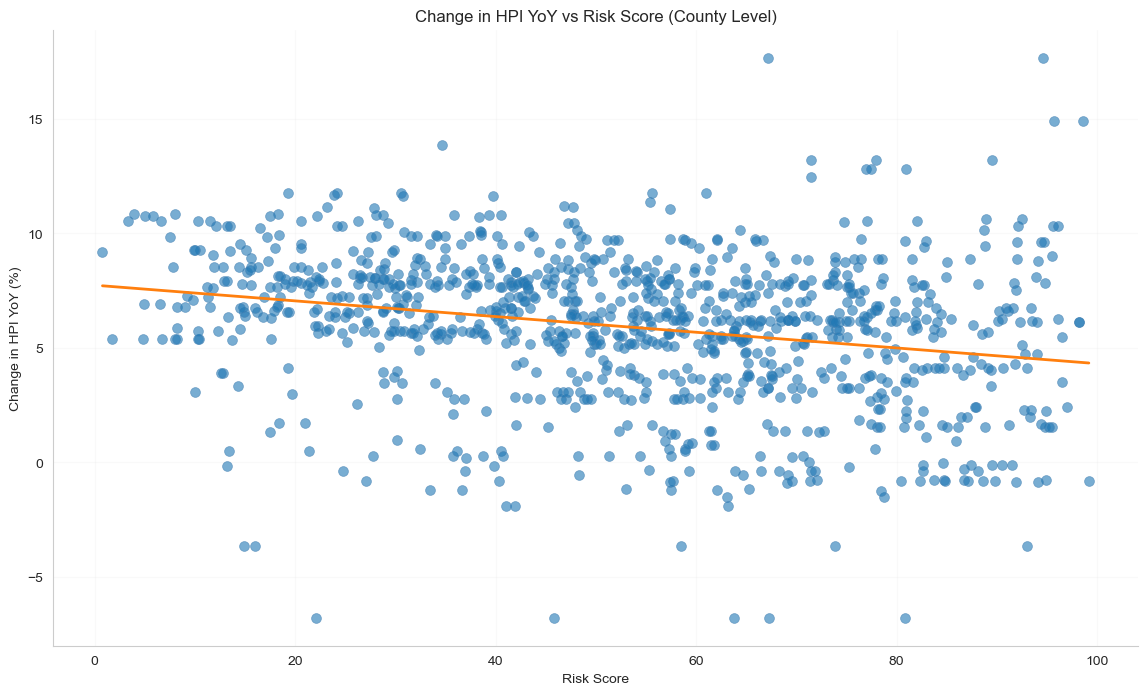

In [182]:
import seaborn as sns

# print(geo_corr.shape)
x = df["risk_score"].astype(float).values
y = df["hpi_yoy"].astype(float).values
# Fit line
X = sm.add_constant(x)
beta = sm.OLS(y, X, missing="drop").fit().params
xline = np.linspace(np.nanmin(x), np.nanmax(x), 100)
yline = beta[0] + beta[1] * xline


# Plot
sns.set_style("whitegrid")  # or "ticks" for minimal gridlines

plt.figure(figsize=(14, 8))
ax = sns.scatterplot(
    x=x, y=y, alpha=0.6, edgecolor="steelblue", s=50, color="C0", label="MSA"
)
sns.lineplot(x=xline, y=yline, ax=ax, color="C1", lw=2)

# Averages are for MSA level
# ax.set(
#     xlabel="Average Risk Score",
#     ylabel="Average HPI YoY (%)",
#     title="Average HPI YoY vs Average Risk (County-level)",
# )

ax.set(
    xlabel="Risk Score",
    ylabel="Change in HPI YoY (%)",
    title="Change in HPI YoY vs Risk Score (County Level)",
)

ax.grid(True, axis="y", linestyle="-", alpha=0.1)
ax.grid(True, axis="x", linestyle="-", alpha=0.1)

sns.despine(top=True, right=True)

ax.legend_.remove()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Create 4 quartiles: Q1 (Low), Q2, Q3, Q4 (High)
df["risk_quartile"] = pd.qcut(
    df["risk_score"], 4, labels=["Low", "Medium-Low", "Medium-High", "High"]
)

# Inspect group means
group_means = df.groupby("risk_quartile")["hpi_yoy"].mean().round(3)
print(group_means)

risk_quartile
Low            0.358
Medium-Low     0.396
Medium-High    0.404
High           0.316
Name: hpi_yoy, dtype: float64


/var/folders/d6/ctkwr8y15b3fjbrsjdbc2zt80000gn/T/ipykernel_50231/2989997684.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["risk_quartile"] = pd.qcut(df["risk_score"], 4, labels=["Low", "Medium-Low", "Medium-High", "High"])
/var/folders/d6/ctkwr8y15b3fjbrsjdbc2zt80000gn/T/ipykernel_50231/2989997684.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby("risk_quartile")["hpi_yoy"].mean().round(3)


In [124]:
from scipy.stats import ttest_ind

low = df.loc[df["risk_quartile"] == "Low", "hpi_yoy"].dropna()
high = df.loc[df["risk_quartile"] == "High", "hpi_yoy"].dropna()

t_stat, p_val = ttest_ind(low, high, equal_var=False)  # Welch's t-test (safer)
print(f"T-statistic = {t_stat:.3f}, p-value = {p_val:.4f}")

T-statistic = 1.579, p-value = 0.1144


In [125]:
from scipy.stats import f_oneway

q1 = df.loc[df["risk_quartile"] == "Low", "hpi_yoy"]
q2 = df.loc[df["risk_quartile"] == "Medium-Low", "hpi_yoy"]
q3 = df.loc[df["risk_quartile"] == "Medium-High", "hpi_yoy"]
q4 = df.loc[df["risk_quartile"] == "High", "hpi_yoy"]

f_stat, p_val = f_oneway(q1, q2, q3, q4)
print(f"F-statistic = {f_stat:.3f}, p-value = {p_val:.4f}")

F-statistic = 4.267, p-value = 0.0051


/var/folders/d6/ctkwr8y15b3fjbrsjdbc2zt80000gn/T/ipykernel_50231/4235768919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="risk_quartile", y="hpi_yoy", data=df, palette="Blues", showmeans=True)


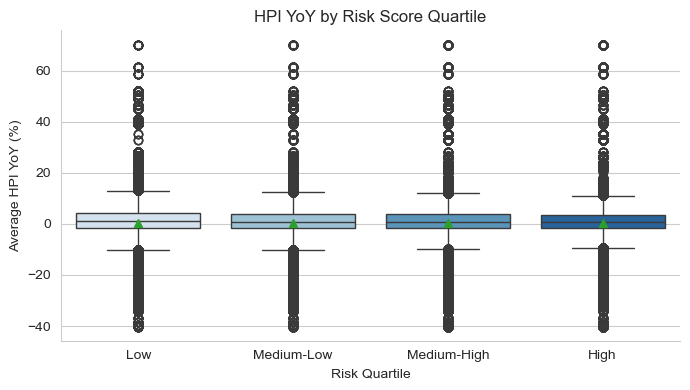

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
sns.boxplot(x="risk_quartile", y="hpi_yoy", data=df, palette="Blues", showmeans=True)
sns.despine(top=True, right=True)
plt.title("HPI YoY by Risk Score Quartile")
plt.xlabel("Risk Quartile")
plt.ylabel("Average HPI YoY (%)")
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df["hpi_yoy"], groups=df["risk_quartile"], alpha=0.05)
print(tukey.summary())

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj   lower  upper  reject
-------------------------------------------------------------
       High         Low   0.0414 0.4336 -0.0292  0.112  False
       High Medium-High   0.0874  0.008  0.0168  0.158   True
       High  Medium-Low   0.0796 0.0197   0.009 0.1502   True
        Low Medium-High    0.046 0.3369 -0.0246 0.1166  False
        Low  Medium-Low   0.0382 0.5052 -0.0324 0.1088  False
Medium-High  Medium-Low  -0.0078  0.992 -0.0784 0.0628  False
-------------------------------------------------------------
